In [1]:
%matplotlib widget
from matplotlib import pyplot as plt
import numpy as np
from astropy import cosmology as cosmo
from astropy import units as u
from astropy import constants as c
from astropy.visualization import quantity_support
quantity_support()

<astropy.visualization.units.quantity_support.<locals>.MplQuantityConverter at 0x28eee3af710>

In [2]:
LCDM = cosmo.Planck18

In [3]:
max_xi = 30*np.pi
step = np.pi/10
xi = np.arange(0, max_xi, step)
xi = np.concatenate([-max_xi+xi, xi])
z = np.concatenate([np.linspace(-.3, 0, 21), np.logspace(-2, 10, 101)])
a = 1/(1+z)
t0 = LCDM.age(0)
t = (LCDM.age(z)/t0).to_value('')
Dc = (LCDM.comoving_distance(z)*LCDM.H0/c.c).to_value('')

c:\Users\Daniel Universidad\AppData\Local\Programs\Python\Python311\Lib\site-packages\astropy\cosmology\flrw\base.py:1076: IntegrationWarning: The algorithm does not converge.  Roundoff error is detected
  in the extrapolation table.  It is assumed that the requested tolerance
  cannot be achieved, and that the returned result (if full_output = 1) is 
  the best which can be obtained.
  return quad(self._inv_efunc_scalar, z1, z2, args=self._inv_efunc_scalar_args)[0]
c:\Users\Daniel Universidad\AppData\Local\Programs\Python\Python311\Lib\site-packages\astropy\cosmology\flrw\base.py:1076: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  return quad(self._inv_efunc_scalar, z1, z2, args=self._inv_efunc_scalar_args)[0]


In [4]:
z_e = 1
t_e = (LCDM.age(z_e)/t0).to_value('')
Dc_e = (LCDM.comoving_distance(z_e)*LCDM.H0/c.c).to_value('')

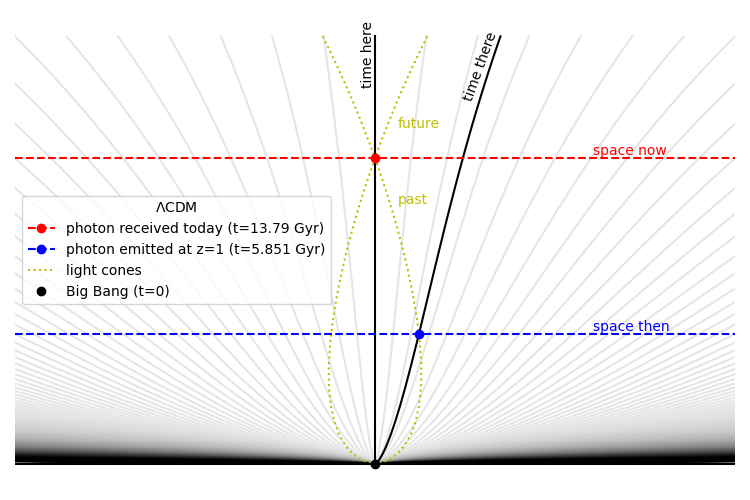

In [5]:
plt.close('LCDM')
fig = plt.figure('LCDM', figsize=(7.5, 5))
axes = fig.subplots(nrows=1, ncols=1, squeeze=False,
                    sharex='col', sharey='row',
                    gridspec_kw={'hspace': 0, 'wspace': 0}
                   )

ax = axes[0, 0]
ax.annotate('time here', xy=[.48, .85], rotation=90, xycoords='axes fraction')
ax.set_xlim(-np.pi, np.pi)
ax.annotate('space now', xy=[1.9, 1.01], color='r')
ax.annotate('space then', xy=[1.9, t_e+.01], color='b')

x = Dc_e
ax.plot(x*a, t, 'k-', alpha=1)
ax.annotate('time there', xy=[.62, .82], rotation=70, xycoords='axes fraction')
for x in xi:
    ax.plot(x*a, t, 'k-', alpha=.1)


light_cone, = ax.plot(Dc*a, t, 'y:', label='light cones')
ax.plot(-Dc*a, t, 'y:', label='light cones')
ax.plot([0, 0], [t[0], t[-1]], 'k-')
ax.annotate('future', xy=[.2, 1.1], color='y')
ax.annotate('past', xy=[.2, .85], color='y')

present_time = ax.axhline(1, c='r', ls='--')
photon_received, = ax.plot(0, 1, 'ro--', label=f'photon received today (t={t0:.2f})')
emission_time = ax.axhline(t_e, c='b', ls='--')
photon_emitted, = ax.plot(Dc_e/(1+z_e), t_e, 'bo--', label=f'photon emitted at z={z_e} (t={t_e*t0:.3f})')
ax.axhline(0, c='k')
big_bang, = ax.plot(0, 0, 'ko', label='Big Bang (t=0)')
ax.legend(handles=[photon_received, photon_emitted, light_cone, big_bang], title=r'$\Lambda$CDM', loc='center left')

for ax in axes.flatten():
    ax.axis('off')
    #ax.tick_params(which='both', direction='in')
    #ax.grid(alpha=.5)
fig.set_tight_layout(True)
plt.savefig('figures/LCDM.pdf')
plt.show()

In [6]:
max_xi = np.pi
step = np.pi/20
xi = np.arange(0, max_xi, step)
xi = np.concatenate([-max_xi+xi, xi])
z = np.concatenate([np.linspace(-.2, 0, 21), np.logspace(-2, 10, 101)])
a = 1/(1+z)
H0 = 70.2*u.km/u.s/u.Mpc
t0 = (1/H0).to_value(u.Gyr)
t = 1/(1+z)
Dc = np.log(1+z)

In [7]:
z_e = 1
t_e = 1/(1+z_e)
Dc_e = np.log(1+z_e)

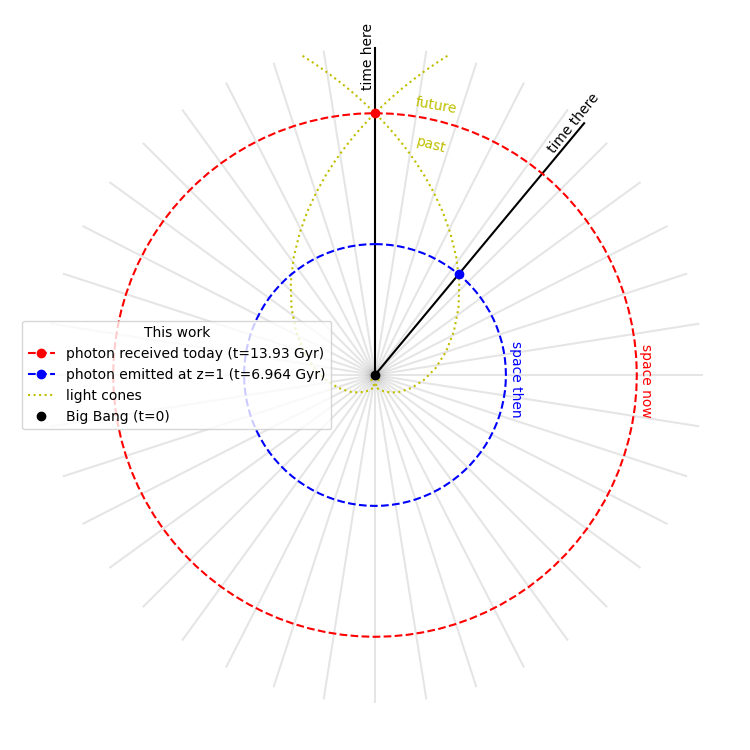

In [8]:
plt.close('finite_universe')
fig = plt.figure('finite_universe', figsize=(7.5, 7.5))
axes = fig.subplots(nrows=1, ncols=1, squeeze=False,
                    sharex='col', sharey='row',
                    gridspec_kw={'hspace': 0, 'wspace': 0},
                   )

ax = axes[0, 0]
ax.set_aspect('equal')
ax.annotate('time here', xy=[.48, .9], rotation=90, xycoords='axes fraction')
#ax.set_xlim(-np.pi, np.pi)
#ax.annotate('space', xy=[.9, 0.48], xycoords='axes fraction')

x = Dc_e
ax.plot([0, t[0]*np.sin(x)], [0, t[0]*np.cos(x)], 'k-')
ax.annotate('time there', xy=[.65, .85], rotation=51)

for x in xi:
    ax.plot([0, t[0]*np.sin(x)], [0, t[0]*np.cos(x)], 'k-', alpha=.1)

ax.annotate('space now', xy=[1.01, -.15], color='r', rotation=-90)
ax.annotate('space then', xy=[t_e+.01, -.15], color='b', rotation=-90)

light_cone, = ax.plot(np.sin(Dc)*t, np.cos(Dc)*t, 'y:', label='light cones')
ax.plot(np.sin(-Dc)*t, np.cos(-Dc)*t, 'y:')
ax.annotate('future', xy=[.15, 1], color='y', rotation=-10)
ax.annotate('past', xy=[.15, .85], color='y', rotation=-15)
ax.plot([0, 0], [t[0], t[-1]], 'k-')

theta = np.linspace(0, 2*np.pi, 101)
ax.plot(np.sin(theta), np.cos(theta), 'r--')
photon_received, = ax.plot(0, 1, 'ro--', label=f'photon received today (t={t0:.2f} Gyr)')
ax.plot(np.sin(theta)/(1+z_e), np.cos(theta)/(1+z_e), 'b--')
photon_emitted, = ax.plot(np.sin(Dc_e)*t_e, np.cos(Dc_e)*t_e, 'bo--', label=f'photon emitted at z={z_e} (t={t_e*t0:.3f} Gyr)')
big_bang, = ax.plot(0, 0, 'ko', label='Big Bang (t=0)')
ax.legend(handles=[photon_received, photon_emitted, light_cone, big_bang], title='This work', loc='center left')

for ax in axes.flatten():
    ax.axis('off')
    #ax.tick_params(which='both', direction='in')
    #ax.grid(alpha=.5)
fig.set_tight_layout(True)
plt.savefig('figures/finite_universe.pdf')
plt.show()